## 1. Import Library and Setup Configuration

In [52]:
# import necessary libraries
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer
from health_multimodal.image import get_image_inference
from health_multimodal.image.utils import ImageModelType

In [53]:
# setup reproducibility
def seed_everything(seed=42):
    import random
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

In [54]:
# setup configuration
config = {
    "experiment": "exp_001",
    "stage": "stage_a",

    "data": {
        "train_path": r"D:\VLM-Research_Task-C\data\processed\chexpert_plus\train.parquet",
        "dev_path": r"D:\VLM-Research_Task-C\data\processed\chexpert_plus\dev_internal.parquet",
        "test_path": r"D:\VLM-Research_Task-C\data\processed\chexpert_plus\test.parquet",
        "image_col": "actual_image_path",
        "label_suffix": "_label",
        "max_text_length": 512
    },
    
    "model": {
        "text_encoder_name": "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext",
        "hidden_dim": 1024,          # must match BioGPT's hidden_size (will be used in meeting-stage)
        "num_queries": 32,
        "num_layers": 2,
        "num_heads": 8,
        "dropout": 0.1
    },
    
    "train": {
        "batch_size": 16,
        "num_epochs": 15,
        "lr": 1.0e-4,
        "weight_decay": 1.0e-4,
        "grad_clip_norm": 1.0,
        "early_stopping_patience": 3,
        "num_workers": 0,
        "seed": 42,
        "checkpoint_dir": r"D:\VLM-Research_Task-C\output\exp_001\stage_a\checkpoints",
        "log_dir": r"D:\VLM-Research_Task-C\output\exp_001\stage_a\logs",
        "plot_dir": r"D:\VLM-Research_Task-C\output\exp_001\stage_a\plots",
        "best_model_filename": "stage_a_best.pt"
    },

    "output": {
        "checkpoint_dir": r"D:\VLM-Research_Task-C\output\exp_001\stage_a\checkpoints",
        "log_dir": r"D:\VLM-Research_Task-C\output\exp_001\stage_a\logs",
        "plot_dir": r"D:\VLM-Research_Task-C\output\exp_001\stage_a\plots",
        "best_model_filename": "stage_a_best.pt"
    },
    
    "device": "cuda"
}

# create output directories
for key in ["checkpoint_dir", "log_dir", "plot_dir"]:
    os.makedirs(config["output"][key], exist_ok=True)

In [55]:
# define device, if GPU doesn't exist, it'll fallback to CPU usage
device = torch.device(config['device'] if torch.cuda.is_available() else 'cpu')
print(f"using device: {device}")

using device: cuda


## 2. Load Data

In [56]:
df_train = pd.read_parquet(config['data']['train_path'])
df_dev = pd.read_parquet(config['data']['dev_path'])
df_test = pd.read_parquet(config['data']['test_path'])

In [57]:
# quick exploration

# dataset dimension
print(f"train set: {df_train.shape[0]} rows & {df_train.shape[1]} columns")
print(f"dev set: {df_dev.shape[0]} rows & {df_dev.shape[1]} columns")
print(f"test set: {df_test.shape[0]} rows & {df_test.shape[1]} columns")

# CXR pathology multilabel
# not directly used in Stage-A training, but needed for dataset interface
label_cols = [col for col in df_train.columns if col.endswith(config['data']['label_suffix'])]
print(f"label columns ({len(label_cols)}): {label_cols}")

# make sure there are 14 CXR pathology labels
assert len(label_cols) == 14, "there have to be 14 CXR pathology labels"

train set: 189529 rows & 77 columns
dev set: 33563 rows & 77 columns
test set: 234 rows & 77 columns
label columns (14): ['Enlarged Cardiomediastinum_label', 'Cardiomegaly_label', 'Lung Opacity_label', 'Lung Lesion_label', 'Edema_label', 'Consolidation_label', 'Pneumonia_label', 'Atelectasis_label', 'Pneumothorax_label', 'Pleural Effusion_label', 'Pleural Other_label', 'Fracture_label', 'Support Devices_label', 'No Finding_label']


## 3. Training Utilities

### 3.1 Dataset Class

In [58]:
class StageADataset(Dataset):
    def __init__(self, df, image_col, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_col = image_col
        self.transform = transform

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row[self.image_col]
        try:
            image = Image.open(img_path).convert('L')
        except FileNotFoundError:
            print(f"warning: image not found {img_path}, returning zeros.")
            image = Image.new('L', (224, 224))
        if self.transform:
            image = self.transform(image)
        target_text = row["target_report_text"]
        return image, target_text

### 3.2 Load BioViL-T Image Encoder

In [59]:
# load BioViL-T image encoder
image_engine = get_image_inference(ImageModelType.BIOVIL_T)
biovilt_transform = image_engine.transform
bio_model = image_engine.model
bio_model.to(device)
bio_model.eval()

# freeze BioViL-T
for param in bio_model.parameters():
    param.requires_grad = False

print("biovil-t loaded successfully (frozen)")

biovil-t loaded successfully (frozen)


In [60]:
# detect vision hidden dimension
sample_row = df_train.iloc[0]
sample_img_path = sample_row[config['data']['image_col']]
try:
    sample_img = Image.open(sample_img_path).convert('L')
except FileNotFoundError:
    sample_img = Image.new('L', (224, 224))

sample_pixel_values = biovilt_transform(sample_img).unsqueeze(0).to(device)

with torch.no_grad():
    dummy_out = bio_model(sample_pixel_values)
    
    if hasattr(dummy_out, 'patch_embeddings'):
        features = dummy_out.patch_embeddings
        print("using patch_embeddings")
    elif hasattr(dummy_out, 'last_hidden_state'):
        features = dummy_out.last_hidden_state
        print("using last_hidden_state")
    else:
        if isinstance(dummy_out, torch.Tensor):
            features = dummy_out
            print("using raw tensor output")
        else:
            try:
                features = bio_model.encoder(sample_pixel_values)
                print("using encoder output")
            except:
                raise RuntimeError("Cannot extract features from BioViL-T output")
    
    if features.dim() == 3:
        vision_dim = features.shape[-1]
    elif features.dim() == 4:
        vision_dim = features.shape[1]
    else:
        vision_dim = features.shape[-1]
    
    # sanity check: ensure vision_dim is valid
    if vision_dim < 100:
        print(f"warning: detected vision_dim={vision_dim}, which is suspiciously small.")
        print("fallback to 512 (default patch_embeddings dimension).")
        vision_dim = 512

config['vision_dim'] = vision_dim
print(f"vision hidden dimension: {vision_dim}")

using patch_embeddings
vision hidden dimension: 512


In [61]:
# define feature extractor function
def extract_spatial_features(backbone, images):
    with torch.no_grad():
        out = backbone(images)
        if hasattr(out, 'patch_embeddings'):
            features = out.patch_embeddings
            if features.dim() == 4:
                B, C, H, W = features.shape
                features = features.flatten(2).transpose(1, 2)  # (B, H*W, C)
            return features
        elif hasattr(out, 'last_hidden_state'):
            features = out.last_hidden_state
            if features.dim() == 4:
                B, C, H, W = features.shape
                features = features.flatten(2).transpose(1, 2)
            return features
        else:
            raise ValueError("BioViL-T output format not recognized")

### 3.3 Load BiomedBERT Text Encoder

In [62]:
# load PubMedBERT text encoder
text_encoder = AutoModel.from_pretrained(config['model']['text_encoder_name']).to(device)
text_encoder.eval()

# freeze PubMedBERT
for param in text_encoder.parameters():
    param.requires_grad = False

tokenizer = AutoTokenizer.from_pretrained(config['model']['text_encoder_name'])
print(f"text encoder loaded: {config['model']['text_encoder_name']}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


text encoder loaded: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext


min: 7
max: 876
mean: 79.7
95th percentile: 170.0
99th percentile: 256.0


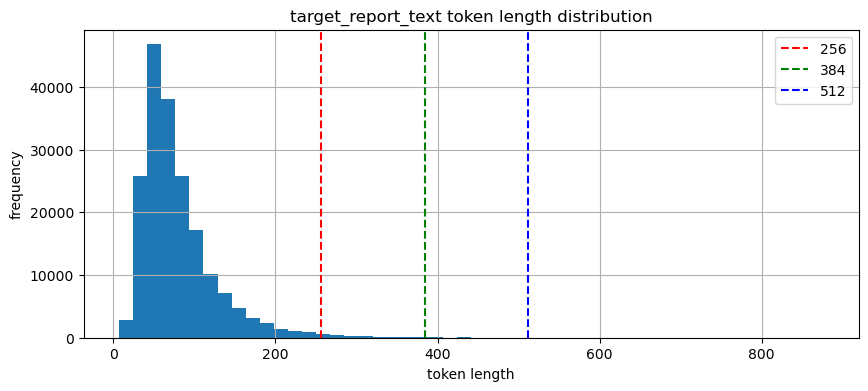

In [63]:
# quick exploration to determine the number of `max_text_length`
sample_texts = df_train['target_report_text'].tolist()
token_lengths = [len(tokenizer.encode(t, add_special_tokens=True)) for t in sample_texts]

print(f"min: {min(token_lengths)}")
print(f"max: {max(token_lengths)}")
print(f"mean: {np.mean(token_lengths):.1f}")
print(f"95th percentile: {np.percentile(token_lengths, 95):.1f}")
print(f"99th percentile: {np.percentile(token_lengths, 99):.1f}")

plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=50)
plt.axvline(256, color='r', linestyle='--', label='256')
plt.axvline(384, color='g', linestyle='--', label='384')
plt.axvline(512, color='b', linestyle='--', label='512')
plt.xlabel('token length')
plt.ylabel('frequency')
plt.legend()
plt.title('target_report_text token length distribution')
plt.grid(True)
plt.show()

### 3.4 Create Dataset and Dataloader

In [64]:
train_ds = StageADataset(df_train, config['data']['image_col'], transform=biovilt_transform)
dev_ds = StageADataset(df_dev, config['data']['image_col'], transform=biovilt_transform)

train_loader = DataLoader(train_ds, batch_size=config['train']['batch_size'], shuffle=True, num_workers=config['train']['num_workers'], pin_memory=True)
dev_loader = DataLoader(dev_ds, batch_size=config['train']['batch_size'], shuffle=False, num_workers=config['train']['num_workers'], pin_memory=True)

print(f"train batches: {len(train_loader)}, dev batches: {len(dev_loader)}")

train batches: 11846, dev batches: 2098


### 3.5 Define Alignment Module and ITM Head

In [65]:
class AlignmentModule(nn.Module):
    """
    Lightweight alignment module: learnable queries cross-attend to visual features.
    Uses nn.TransformerDecoder (cross-attention only, no joint self-attention with text).
    """
    def __init__(self, visual_feature_dim, hidden_dim, num_queries=32, num_layers=2, num_heads=8, dropout=0.1):
        super().__init__()
        self.num_queries = num_queries
        self.hidden_dim = hidden_dim
        self.query_embeddings = nn.Parameter(torch.randn(num_queries, hidden_dim) * 0.02)
        self.visual_proj = nn.Linear(visual_feature_dim, hidden_dim)
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            batch_first=True
        )
        self.cross_attention = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.output_norm = nn.LayerNorm(hidden_dim)

    def forward(self, visual_features):
        batch_size = visual_features.size(0)
        memory = self.visual_proj(visual_features)  # [B, N_patches, hidden_dim]
        queries = self.query_embeddings.unsqueeze(0).expand(batch_size, -1, -1)
        soft_tokens = self.cross_attention(tgt=queries, memory=memory)
        return self.output_norm(soft_tokens)  # [B, num_queries, hidden_dim]

In [66]:
class ITMHead(nn.Module):
    """Binary classifier for Image-Text Matching (match vs no-match)."""
    def __init__(self, embed_dim, hidden_dim=None, dropout=0.1):
        super().__init__()
        hidden_dim = hidden_dim or embed_dim
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2)  # [no-match, match]
        )

    def forward(self, joint_embeds):
        return self.classifier(joint_embeds)

In [67]:
# instantiate modules
alignment_module = AlignmentModule(
    visual_feature_dim=config['vision_dim'],
    hidden_dim=config['model']['hidden_dim'],
    num_queries=config['model']['num_queries'],
    num_layers=config['model']['num_layers'],
    num_heads=config['model']['num_heads'],
    dropout=config['model']['dropout']
).to(device)

itm_head = ITMHead(embed_dim=config['model']['hidden_dim'], dropout=config['model']['dropout']).to(device)

# text projection layer: BiomedBERT hidden_size (768) -> hidden_dim (1024)
text_proj = nn.Linear(text_encoder.config.hidden_size, config['model']['hidden_dim']).to(device)

print(f"alignment module initialized with {sum(p.numel() for p in alignment_module.parameters())/1e6:.2f}M params")
print(f"itm_head: {sum(p.numel() for p in itm_head.parameters())/1e6:.2f}M params")
print(f"text_proj: {sum(p.numel() for p in text_proj.parameters())/1e6:.2f}M params")

alignment module initialized with 34.15M params
itm_head: 2.10M params
text_proj: 0.79M params


### 3.6 Define Loss Functions

In [68]:
def contrastive_loss(visual_embeds, text_embeds, temperature=0.07):
    """Symmetric contrastive loss (CLIP-style) with in-batch negatives."""
    visual_embeds = torch.nn.functional.normalize(visual_embeds, dim=-1)
    text_embeds = torch.nn.functional.normalize(text_embeds, dim=-1)
    sim_matrix = (visual_embeds @ text_embeds.T) / temperature  # [B, B]
    labels = torch.arange(sim_matrix.size(0), device=sim_matrix.device)
    loss_i2t = torch.nn.functional.cross_entropy(sim_matrix, labels)
    loss_t2i = torch.nn.functional.cross_entropy(sim_matrix.T, labels)
    loss = (loss_i2t + loss_t2i) / 2
    return loss, sim_matrix.detach()

In [69]:
def mine_hard_negatives(similarity_matrix):
    """For each row, find the hardest negative (highest similarity wrong pair)."""
    batch_size = similarity_matrix.size(0)
    diag_mask = torch.eye(batch_size, device=similarity_matrix.device, dtype=torch.bool)
    masked_sim = similarity_matrix.masked_fill(diag_mask, float("-inf"))
    return masked_sim.argmax(dim=1)  # [B]

In [70]:
def itm_loss(visual_embeds, text_embeds, hard_neg_idx, itm_head):
    """ITM loss with hard negatives mined from similarity matrix."""
    # positive pairs
    pos_logits = itm_head(torch.cat([visual_embeds, text_embeds], dim=-1))  # [B, 2]
    # negative pairs: image vs hardest negative text
    neg_text_embeds = text_embeds[hard_neg_idx]
    neg_logits = itm_head(torch.cat([visual_embeds, neg_text_embeds], dim=-1))
    logits = torch.cat([pos_logits, neg_logits], dim=0)
    labels = torch.cat([
        torch.ones(pos_logits.size(0), dtype=torch.long, device=logits.device),
        torch.zeros(neg_logits.size(0), dtype=torch.long, device=logits.device)
    ])
    return torch.nn.functional.cross_entropy(logits, labels)

In [71]:
def encode_text_batch(tokenizer, text_encoder, texts, device, max_length=256):
    """Mean-pooled text embedding for a batch of texts using frozen text encoder."""
    encoded = tokenizer(texts, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(device)
    with torch.no_grad():
        output = text_encoder(**encoded)
    mask = encoded["attention_mask"].unsqueeze(-1).float()
    summed = (output.last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-6)
    return summed / counts  # [B, text_hidden_size]

In [72]:
def compute_retrieval_accuracy(similarity_matrix):
    """In-batch Recall@1 and Recall@5 for image-to-text retrieval."""
    batch_size = similarity_matrix.size(0)
    targets = torch.arange(batch_size, device=similarity_matrix.device)
    ranks = similarity_matrix.argsort(dim=1, descending=True)
    correct_pos = (ranks == targets.unsqueeze(1)).float().argmax(dim=1)
    recall1 = (correct_pos < 1).float().mean().item()
    recall5 = (correct_pos < min(5, batch_size)).float().mean().item()
    return {"recall@1": recall1, "recall@5": recall5}

## 4. Train Loop

In [73]:
trainable_params = (list(alignment_module.parameters()) + list(itm_head.parameters()) + list(text_proj.parameters()))
optimizer = torch.optim.AdamW(trainable_params, lr=config['train']['lr'], weight_decay=config['train']['weight_decay'])

early_stop_counter = 0
best_val_recall1 = 0.0
train_contrastive_losses, train_itm_losses = [], []
val_contrastive_losses, val_itm_losses = [], []
val_recall1s, val_recall5s = [], []
val_itm_accuracies = []



print("starting training (optimizer: adamw, early stopping based on recall@1)")
for epoch in range(1, config['train']['num_epochs'] + 1):
    # ----- training phase -----
    alignment_module.train()
    itm_head.train()
    train_c_loss, train_i_loss = 0.0, 0.0
    
    for images, texts in tqdm(train_loader, desc=f"epoch {epoch}/{config['train']['num_epochs']} (train)"):
        images = images.to(device)
        
        with torch.no_grad():
            visual_features = extract_spatial_features(bio_model, images)  # [B, N_patches, D]
        
        soft_tokens = alignment_module(visual_features)                 # [B, num_queries, hidden_dim]
        visual_embeds = soft_tokens.mean(dim=1)                         # [B, hidden_dim]

        text_embeds_raw = encode_text_batch(tokenizer, text_encoder, list(texts), device, config['data']['max_text_length'])
        text_embeds = text_proj(text_embeds_raw)                        # [B, hidden_dim]

        # contrastive loss
        c_loss, sim_matrix = contrastive_loss(visual_embeds, text_embeds)
        
        # ITM loss with hard negatives
        hard_neg_idx = mine_hard_negatives(sim_matrix)
        i_loss = itm_loss(visual_embeds, text_embeds, hard_neg_idx, itm_head)

        loss = c_loss + i_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_params, config['train']['grad_clip_norm'])
        optimizer.step()

        train_c_loss += c_loss.item()
        train_i_loss += i_loss.item()

    train_c_loss /= len(train_loader)
    train_i_loss /= len(train_loader)
    train_contrastive_losses.append(train_c_loss)
    train_itm_losses.append(train_i_loss)

    # ----- validation phase -----
    alignment_module.eval()
    itm_head.eval()
    val_c_loss, val_i_loss = 0.0, 0.0
    val_recall1_sum, val_recall5_sum, val_itm_acc_sum = 0.0, 0.0, 0.0
    
    with torch.no_grad():
        for images, texts in tqdm(dev_loader, desc=f"epoch {epoch}/{config['train']['num_epochs']} (val)"):
            images = images.to(device)
            visual_features = extract_spatial_features(bio_model, images)
            soft_tokens = alignment_module(visual_features)
            visual_embeds = soft_tokens.mean(dim=1)

            text_embeds_raw = encode_text_batch(tokenizer, text_encoder, list(texts), device, config['data']['max_text_length'])
            text_embeds = text_proj(text_embeds_raw)

            c_loss, sim_matrix = contrastive_loss(visual_embeds, text_embeds)
            hard_neg_idx = mine_hard_negatives(sim_matrix)
            i_loss = itm_loss(visual_embeds, text_embeds, hard_neg_idx, itm_head)

            val_c_loss += c_loss.item()
            val_i_loss += i_loss.item()

            # retrieval metrics
            retrieval = compute_retrieval_accuracy(sim_matrix)
            val_recall1_sum += retrieval["recall@1"]
            val_recall5_sum += retrieval["recall@5"]

            # ITM head accuracy on positive + negative pairs
            pos_logits = itm_head(torch.cat([visual_embeds, text_embeds], dim=-1))
            neg_logits = itm_head(torch.cat([visual_embeds, text_embeds[hard_neg_idx]], dim=-1))
            pos_correct = (pos_logits.argmax(dim=1) == 1).float().mean()
            neg_correct = (neg_logits.argmax(dim=1) == 0).float().mean()
            val_itm_acc_sum += ((pos_correct + neg_correct) / 2).item()

    n_batches = len(dev_loader)
    val_c_loss /= n_batches
    val_i_loss /= n_batches
    val_recall1 = val_recall1_sum / n_batches
    val_recall5 = val_recall5_sum / n_batches
    val_itm_acc = val_itm_acc_sum / n_batches

    val_contrastive_losses.append(val_c_loss)
    val_itm_losses.append(val_i_loss)
    val_recall1s.append(val_recall1)
    val_recall5s.append(val_recall5)
    val_itm_accuracies.append(val_itm_acc)

    print(f"epoch {epoch}: train_c={train_c_loss:.4f} train_i={train_i_loss:.4f} | "
          f"val_c={val_c_loss:.4f} val_i={val_i_loss:.4f} | "
          f"R@1={val_recall1:.4f} R@5={val_recall5:.4f} ITM_acc={val_itm_acc:.4f}")

    # early stopping & checkpoint based on val_recall1
    if val_recall1 > best_val_recall1:
        best_val_recall1 = val_recall1
        early_stop_counter = 0
        best_model_path = os.path.join(config['output']['checkpoint_dir'], config['output']['best_model_filename'])
        torch.save({
            'epoch': epoch,
            'alignment_module_state_dict': alignment_module.state_dict(),
            'itm_head_state_dict': itm_head.state_dict(),
            'text_proj_state_dict': text_proj.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_recall1': best_val_recall1,
        }, best_model_path)
        print(f"  -> new best model saved (recall@1={val_recall1:.4f})")
    else:
        early_stop_counter += 1
        if early_stop_counter >= config['train']['early_stopping_patience']:
            print(f"early stopping triggered at epoch {epoch}")
            break

print(f"\ntraining finished. best validation recall@1: {best_val_recall1:.4f}")

starting training (optimizer: adamw, early stopping based on recall@1)


epoch 1/15 (train):   0%|          | 0/11846 [00:00<?, ?it/s]

KeyboardInterrupt: 

note:
- If `recall@1` plateaus early or remains low, consider upgrading to `Blip2QFormerModel`.

## 5. Model Evaluation

In [ ]:
# contrastive loss
plt.figure(figsize=(10, 4))
plt.plot(train_contrastive_losses, label='train contrastive')
plt.plot(val_contrastive_losses, label='val contrastive')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('contrastive loss (train vs dev)')
plt.grid(True)
plt.savefig(os.path.join(config['output']['plot_dir'], 'contrastive_loss.png'), dpi=150, bbox_inches='tight')
plt.show()

# ITM loss
plt.figure(figsize=(10, 4))
plt.plot(train_itm_losses, label='train ITM')
plt.plot(val_itm_losses, label='val ITM')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('ITM loss (train vs dev)')
plt.grid(True)
plt.savefig(os.path.join(config['output']['plot_dir'], 'itm_loss.png'), dpi=150, bbox_inches='tight')
plt.show()

# recall and ITM accuracy
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.plot(val_recall1s, label='Recall@1')
plt.plot(val_recall5s, label='Recall@5')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.title('retrieval accuracy (dev)')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(val_itm_accuracies, label='ITM accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.title('ITM head accuracy (dev)')
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(config['output']['plot_dir'], 'retrieval_itm_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary of Stage-A

In [ ]:
summary = f"""
====================================================================
stage-a training summary
====================================================================
experiment: {config['experiment']}
stage: {config['stage']}
device: {device}

dataset:
  - train: {len(df_train)} samples
  - dev: {len(df_dev)} samples
  - test: {len(df_test)} samples

model:
  - alignment module: lightweight (nn.TransformerDecoder, cross-attention only)
  - hidden dimension: {config['model']['hidden_dim']}
  - num queries: {config['model']['num_queries']}
  - num layers: {config['model']['num_layers']}
  - num heads: {config['model']['num_heads']}
  - dropout: {config['model']['dropout']}
  - text encoder: {config['model']['text_encoder_name']}
  - vision dimension: {config['vision_dim']}

training:
  - batch size: {config['train']['batch_size']}
  - learning rate: {config['train']['lr']}
  - weight decay: {config['train']['weight_decay']}
  - epochs: {len(train_contrastive_losses)}
  - best validation recall@1: {best_val_recall1:.4f}

output directory: {config['output']['checkpoint_dir']}
====================================================================
"""

print(summary)

with open(os.path.join(config['output']['log_dir'], 'training_summary.txt'), 'w') as f:
    f.write(summary)

print("\nall done. stage-a training and evaluation complete.")